In [1]:
# Import dependencies

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np


In [2]:
# Create a set of random latitude and longitude combinations.

lats = np.random.uniform(low=-90.000, high=90.000, size = 1500)

lngs = np.random.uniform(low=-90.000, high=90.000, size = 1500)

lat_lngs = zip(lats, lngs)

lat_lngs

In [3]:
# Add the latitudes and longitudes to a list.

coordinates = list(lat_lngs)
coordinates

[(-5.033670999880911, 3.507602819453311),
 (-32.518145515172215, 55.12637932523049),
 (-86.24690122682809, -42.96997228877672),
 (56.94689439906102, 2.97815986382912),
 (21.42465851115918, 64.65641217099912),
 (13.827536421953212, 73.82683883918912),
 (32.86814172215847, 32.429075657818345),
 (-77.92960432472857, -52.416821350516464),
 (86.77248539531234, 15.393765030168794),
 (86.88839056174879, -56.08700527441424),
 (24.960197781848805, -45.23588368029216),
 (-42.363670508340064, -56.82975543856422),
 (-78.91585542062273, -14.47468727653171),
 (-5.172894832908298, -52.402567092446375),
 (5.118752657080734, -64.70055047271761),
 (32.605691019094934, -37.69369046097569),
 (50.81432568669976, 83.98387052070194),
 (-34.18765469542396, -68.40119741906861),
 (-15.854195693869102, 67.94088534426572),
 (44.17306570833924, -74.59670336832087),
 (86.49768897628209, -81.52185001041133),
 (87.31061025671607, -45.09816162147688),
 (-89.77471877457273, 41.583071035258484),
 (-80.38046353484386, 11

In [4]:
from citipy import citipy


In [5]:
# Create a list fo holding the cities.

cities = []

# Identify the nearest city for each latitude and longitude combination.

for coordinate in coordinates:
    
    city = citipy.nearest_city(coordinate[0], coordinate[1]).city_name
    
    # If the city is unique, then we will add it to the cities list.
    
    if city not in cities:
        
        cities.append(city)
        
# Print the city count to confirm sufficient count.

len(cities)
    
    

613

In [6]:
# Import the requests library.

import requests

# Import the API key.

from config import weather_api_key

In [7]:
# Import the time library and the datetime module from the datetime library.

import time

from datetime import datetime

In [8]:
# Start URL for Weather Map API Call.

url = "https://api.openweathermap.org/data/2.5/weather?units=Imperial&APPID=" + weather_api_key

In [9]:
# Create and empty list to hold hte weather data.

city_data = []

# Print the beginning of the logging.

print("Beginning Data Retrieval      ")
print("------------------------------")

# Create counters.

record_count = 1
set_count = 1


# Loop through all the cities in the list.

for i, city in enumerate(cities):
    
    
    # Group cities in sets of 50 for logging purposes
    
    if (i % 50 == 0 and i >= 50):
        
        set_count += 1
        
        record_count = 1
        
        time.sleep(60)
        
        
    # Create endpoint URL with each city.
    
    city_url = url + "&q=" + city.replace(" ", "+")
    
    
    # Log the URL, record, and set numbers and the city.
    
    print(f"Processing Record {record_count} of Set {set_count} | {city}")
    
    # Add 1 to the record count.
    
    record_count +=1
    
    # Run an API request for each of the cities.
    
    try:
        # Parse out the JSON and retrieve data.
        
        city_weather = requests.get(city_url).json()
        
        # Parse out the needed data.
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = datetime.utcfromtimestamp(city_weather["dt"]).strftime('%Y-%m-%d %H:%M:%S') 

        # Append the City information into city_data list
        city_data.append({"City": city.title(), 
                          "Lat": city_lat, 
                          "Lng": city_lng, 
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})
    
    except:
        print('City not found. Skipping....')
        pass
# Indicate that Data Loading is complete.
                                              
print("------------------------------")
print("Data Retrieval Complete.      ")
print("------------------------------")

Beginning Data Retrieval      
------------------------------
Processing Record 1 of Set 1 | omboue
Processing Record 2 of Set 1 | taolanaro
City not found. Skipping....
Processing Record 3 of Set 1 | ushuaia
Processing Record 4 of Set 1 | varhaug
Processing Record 5 of Set 1 | ormara
Processing Record 6 of Set 1 | bhatkal
Processing Record 7 of Set 1 | damietta
Processing Record 8 of Set 1 | longyearbyen
Processing Record 9 of Set 1 | upernavik
Processing Record 10 of Set 1 | codrington
Processing Record 11 of Set 1 | necochea
Processing Record 12 of Set 1 | cape town
Processing Record 13 of Set 1 | sao felix do xingu
Processing Record 14 of Set 1 | puerto ayacucho
Processing Record 15 of Set 1 | ribeira grande
Processing Record 16 of Set 1 | charyshskoye
Processing Record 17 of Set 1 | san rafael
Processing Record 18 of Set 1 | quatre cocos
Processing Record 19 of Set 1 | potsdam
Processing Record 20 of Set 1 | qaanaaq
Processing Record 21 of Set 1 | port alfred
Processing Record 22 

Processing Record 37 of Set 4 | saint-georges
Processing Record 38 of Set 4 | nagykoros
Processing Record 39 of Set 4 | marrakesh
Processing Record 40 of Set 4 | saint george
Processing Record 41 of Set 4 | itarema
Processing Record 42 of Set 4 | foeni
Processing Record 43 of Set 4 | eyl
Processing Record 44 of Set 4 | havoysund
Processing Record 45 of Set 4 | togur
Processing Record 46 of Set 4 | margate
Processing Record 47 of Set 4 | vila velha
Processing Record 48 of Set 4 | yambio
Processing Record 49 of Set 4 | arlit
Processing Record 50 of Set 4 | crotone
Processing Record 1 of Set 5 | sassandra
Processing Record 2 of Set 5 | abyek
Processing Record 3 of Set 5 | sao filipe
Processing Record 4 of Set 5 | la macarena
Processing Record 5 of Set 5 | jahrom
City not found. Skipping....
Processing Record 6 of Set 5 | ndele
Processing Record 7 of Set 5 | chapais
Processing Record 8 of Set 5 | iralaya
Processing Record 9 of Set 5 | hambantota
Processing Record 10 of Set 5 | bibiani
Proc

Processing Record 27 of Set 8 | kasane
Processing Record 28 of Set 8 | mehamn
Processing Record 29 of Set 8 | paamiut
Processing Record 30 of Set 8 | pavlodar
Processing Record 31 of Set 8 | santa vitoria do palmar
Processing Record 32 of Set 8 | voitsberg
Processing Record 33 of Set 8 | bonthe
Processing Record 34 of Set 8 | lundazi
Processing Record 35 of Set 8 | poopo
Processing Record 36 of Set 8 | acarau
Processing Record 37 of Set 8 | beyneu
Processing Record 38 of Set 8 | samfya
Processing Record 39 of Set 8 | taperoa
Processing Record 40 of Set 8 | tsaratanana
Processing Record 41 of Set 8 | port antonio
Processing Record 42 of Set 8 | sukhoverkovo
City not found. Skipping....
Processing Record 43 of Set 8 | sao tome
Processing Record 44 of Set 8 | marawi
Processing Record 45 of Set 8 | lerwick
Processing Record 46 of Set 8 | turukhansk
Processing Record 47 of Set 8 | estelle
Processing Record 48 of Set 8 | zaranj
Processing Record 49 of Set 8 | aktau
Processing Record 50 of Se

Processing Record 17 of Set 12 | loiza
Processing Record 18 of Set 12 | trelleborg
Processing Record 19 of Set 12 | havelock
Processing Record 20 of Set 12 | pritzwalk
Processing Record 21 of Set 12 | vernashen
Processing Record 22 of Set 12 | bubaque
Processing Record 23 of Set 12 | armacao dos buzios
City not found. Skipping....
Processing Record 24 of Set 12 | los pozos
Processing Record 25 of Set 12 | santhia
Processing Record 26 of Set 12 | altay
Processing Record 27 of Set 12 | nevsehir
Processing Record 28 of Set 12 | gari
Processing Record 29 of Set 12 | okahandja
Processing Record 30 of Set 12 | amapa
Processing Record 31 of Set 12 | atar
Processing Record 32 of Set 12 | nurota
Processing Record 33 of Set 12 | setermoen
Processing Record 34 of Set 12 | nkhata bay
Processing Record 35 of Set 12 | cassilandia
Processing Record 36 of Set 12 | baracoa
Processing Record 37 of Set 12 | dzhusaly
City not found. Skipping....
Processing Record 38 of Set 12 | marchena
Processing Record 

In [10]:
len(city_data)

574

In [11]:
# Convert the array of dictionaries to a Pandas DataFrame.

city_data_df = pd.DataFrame(city_data)

city_data_df.head(10)

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,Omboue,-1.5746,9.2618,70.20,90,63,9.31,GA,2022-06-21 03:52:56
1,Ushuaia,-54.8000,-68.3000,33.46,86,75,23.02,AR,2022-06-21 03:48:18
2,Varhaug,58.6147,5.6457,51.85,78,100,7.72,NO,2022-06-21 03:52:57
3,Ormara,25.2088,64.6357,90.12,48,1,11.61,PK,2022-06-21 03:52:57
4,Bhatkal,13.9667,74.5667,79.59,85,100,5.44,IN,2022-06-21 03:52:58
5,Damietta,31.4165,31.8133,75.09,70,0,6.55,EG,2022-06-21 03:52:58
6,Longyearbyen,78.2186,15.6401,37.85,86,100,11.43,SJ,2022-06-21 03:52:59
7,Upernavik,72.7868,-56.1549,33.21,90,91,9.31,GL,2022-06-21 03:51:09
8,Codrington,-38.2667,141.9667,57.09,62,36,12.10,AU,2022-06-21 03:52:59
9,Necochea,-38.5473,-58.7368,47.57,85,100,8.90,AR,2022-06-21 03:51:04


In [12]:
# Rearrange columns.

new_column_order = ["City", "Country", "Date", "Lat", "Lng", "Max Temp", "Humidity", "Cloudiness", "Wind Speed"]

city_data_df = city_data_df[new_column_order]

city_data_df.head(10)

,City,Country,Date,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed
0,Omboue,GA,2022-06-21 03:52:56,-1.5746,9.2618,70.20,90,63,9.31
1,Ushuaia,AR,2022-06-21 03:48:18,-54.8000,-68.3000,33.46,86,75,23.02
2,Varhaug,NO,2022-06-21 03:52:57,58.6147,5.6457,51.85,78,100,7.72
3,Ormara,PK,2022-06-21 03:52:57,25.2088,64.6357,90.12,48,1,11.61
4,Bhatkal,IN,2022-06-21 03:52:58,13.9667,74.5667,79.59,85,100,5.44
5,Damietta,EG,2022-06-21 03:52:58,31.4165,31.8133,75.09,70,0,6.55
6,Longyearbyen,SJ,2022-06-21 03:52:59,78.2186,15.6401,37.85,86,100,11.43
7,Upernavik,GL,2022-06-21 03:51:09,72.7868,-56.1549,33.21,90,91,9.31
8,Codrington,AU,2022-06-21 03:52:59,-38.2667,141.9667,57.09,62,36,12.10
9,Necochea,AR,2022-06-21 03:51:04,-38.5473,-58.7368,47.57,85,100,8.90


In [13]:
# Create the outpute file (CSV).

output_data_file = "weather_data/cities.csv"

# Export the City_Data into a CSV.

city_data_df.to_csv(output_data_file, index_label="City_ID")

In [14]:
# Extract relevant fields from the DataFrame for plotting.

lats = city_data_df["Lat"]

max_temps = city_data_df["Max Temp"]

humidity = city_data_df["Humidity"]

cloudiness = city_data_df["Cloudiness"]

wind_speed = city_data_df["Wind Speed"]

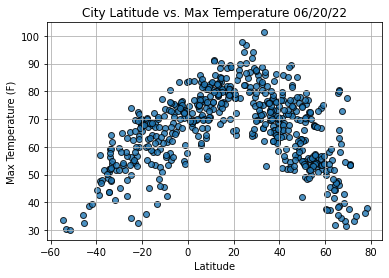

In [15]:
# Import time module.

import time

# Build the scatter plot for latitude vs. max temperature.

plt.scatter(lats,
           max_temps,
           edgecolor="black", linewidths=1, marker="o",
           alpha=0.8, label="Cities")

# Incorporate the other graph properties.

plt.title(f"City Latitude vs. Max Temperature "+ time.strftime('%x'))

plt.ylabel("Max Temperature (F)")

plt.xlabel("Latitude")

plt.grid(True)


# Save the figure.

plt.savefig("weather_data/Fig1.png")


# Show plot.

plt.show()

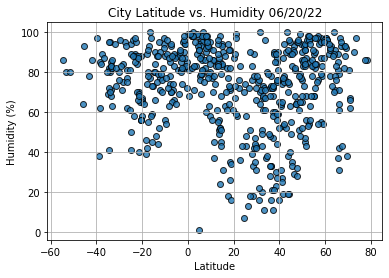

In [16]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            humidity,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Humidity "+ time.strftime("%x"))
plt.ylabel("Humidity (%)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig2.png")
# Show plot.
plt.show()

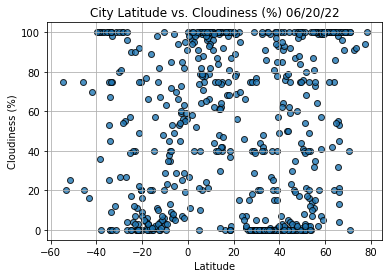

In [17]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            cloudiness,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Cloudiness (%) "+ time.strftime("%x"))
plt.ylabel("Cloudiness (%)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig3.png")
# Show plot.
plt.show()

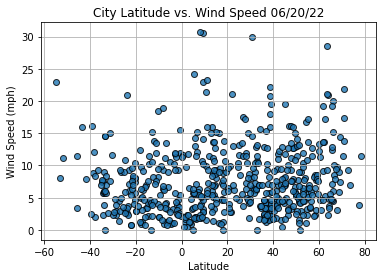

In [18]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            wind_speed,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Wind Speed "+ time.strftime("%x"))
plt.ylabel("Wind Speed (mph)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig4.png")
# Show plot.
plt.show()

In [19]:
# Import linregress

from scipy.stats import linregress


# Create a function to create perform linear regression on teh weather data
# and plot a regression line and the equation with the data.

def plot_linear_regression(x_values, y_values, title, y_label, text_coordinates):
    
    # Run regression on hemisphere weather data.
    
    (slope, intercept, r_value, p_value, std_err) = linregress(x_values, y_values)
    
    
    # Calculate the regression line "y values" from the slope and intercept.
    
    regress_values = x_values * slope + intercept
    
    
    # Get the equation of the line.
    
    line_eq = "y = " + str(round(slope,2)) + "x + " + str(round(intercept,2))
    
    
    # Create a scatter plot and plot the regression line.
    
    plt.scatter(x_values,y_values)
    
    plt.plot(x_values,regress_values,"r")
    
    
    # Annotate the text for the line equation.
    
    plt.annotate(line_eq, text_coordinates, fontsize=15, color="red")
    
    plt.title(title)
    
    plt.xlabel("Latitude")
    
    plt.ylabel(y_label)
    
    plt.show()

In [20]:
# Create Northern and Southern Hemisphere DataFrames.

northern_hemi_df = city_data_df.loc[(city_data_df["Lat"] >=0)]

southern_hemi_df = city_data_df.loc[(city_data_df["Lat"] <0)]

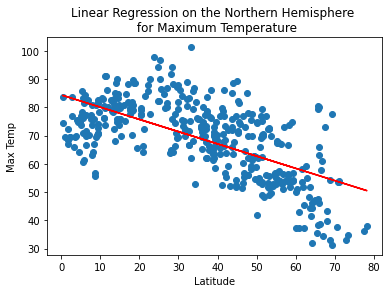

In [21]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Max Temp"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for Maximum Temperature", "Max Temp",(0,275))

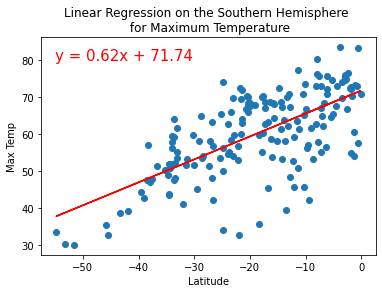

In [30]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Max Temp"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for Maximum Temperature", "Max Temp",(-55,80))

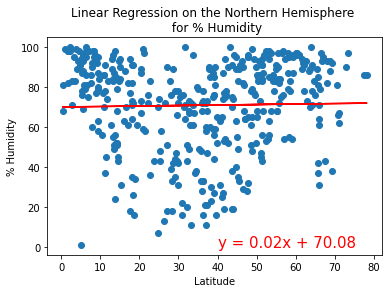

In [31]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Humidity"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for % Humidity", "% Humidity",(40,0))

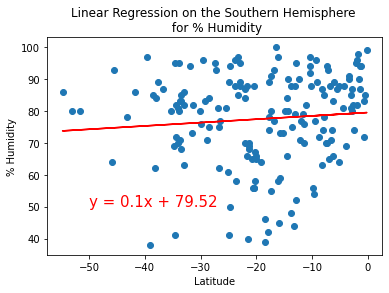

In [32]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Humidity"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for % Humidity", "% Humidity",(-50,50))

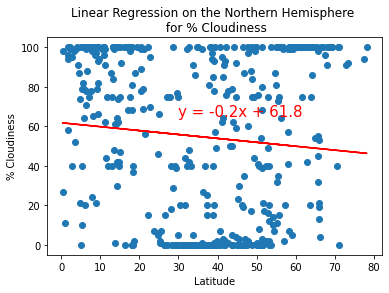

In [36]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Cloudiness"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for % Cloudiness", "% Cloudiness",(30,65))

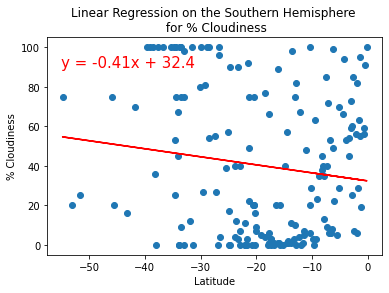

In [38]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Cloudiness"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for % Cloudiness", "% Cloudiness",(-55,90))

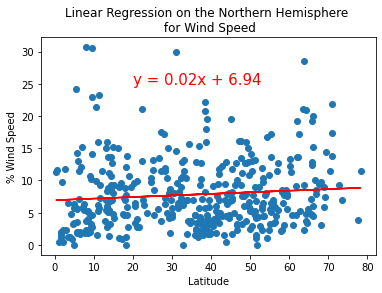

In [39]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Wind Speed"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for Wind Speed", "% Wind Speed",(20,25))

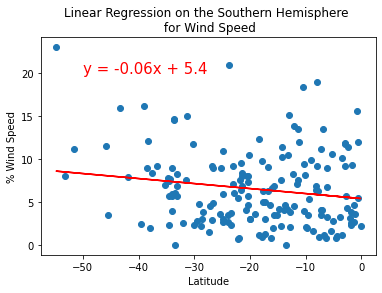

In [40]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Wind Speed"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for Wind Speed", "% Wind Speed",(-50,20))